# 💰 Notebook 2 — Top-p: The Probability Budget

> **The vibe:** You have $100 to spend. Top-p says "only buy from shops until you've spent $90 — ignore the rest."  
> **Key word:** DYNAMIC — the number of shops changes depending on how confident the model is.  
> **Time:** ~10 minutes


In [1]:
# ── Setup ────────────────────────────────────────────────────────────
import numpy as np, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
plt.rcParams.update({'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','text.color':'#e6edf3','axes.labelcolor':'#8b949e',
    'xtick.color':'#8b949e','ytick.color':'#8b949e','grid.color':'#21262d',
    'axes.grid':True,'grid.linewidth':0.5,'font.family':'monospace'})

TOKENS = ['approve','reject','review','escalate','delay','audit','optimize','notify','assign','close']
LOGITS = np.array([2.2,1.8,1.4,0.9,0.2,0.1,-0.3,-0.6,-0.8,-1.0])

def softmax(x): e=np.exp(x-x.max()); return e/e.sum()
PROBS = softmax(LOGITS)

def apply_top_p(probs, p):
    sorted_idx  = np.argsort(probs)[::-1]
    cumsum      = np.cumsum(probs[sorted_idx])
    cutoff      = np.searchsorted(cumsum, p) + 1
    nucleus_idx = sorted_idx[:cutoff]
    filtered    = np.zeros_like(probs)
    filtered[nucleus_idx] = probs[nucleus_idx]
    return filtered / filtered.sum(), cutoff, nucleus_idx

print("✅ Setup done!")
print("Baseline probabilities:")
for t, p in sorted(zip(TOKENS, PROBS), key=lambda x: -x[1]):
    bar = '█' * int(p * 30)
    print(f"  {t:12s} {p:.3f}  {bar}")


✅ Setup done!
Baseline probabilities:
  approve      0.347  ██████████
  reject       0.232  ██████
  review       0.156  ████
  escalate     0.095  ██
  delay        0.047  █
  audit        0.042  █
  optimize     0.028  
  notify       0.021  
  assign       0.017  
  close        0.014  


## 🎬 Graph 1 — Watch the Budget Being Spent

The algorithm walks down the sorted list, spending probability until it hits the budget (p).  
**Everything after the budget is cut.**

Run the cell — you'll see the budget being "spent" in real time across 5 values of p.


/var/folders/xr/skp57kbd3txdt0r466c2q94h0000gp/T/ipykernel_50462/2311308399.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/xr/skp57kbd3txdt0r466c2q94h0000gp/T/ipykernel_50462/2311308399.py:29: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/xr/skp57kbd3txdt0r466c2q94h0000gp/T/ipykernel_50462/2311308399.py:30: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('graph1_topp_budget.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
/var/folders/xr/skp57kbd3txdt0r466c2q94h0000gp/T/ipykernel_50462/2311308399.py:30: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('graph1_topp_budget.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
/Users/nchaur590@cable.comcast.com/Programming/ai-parameter-playbook/.venv/lib/python3.14/site-packages/IPython/core/p

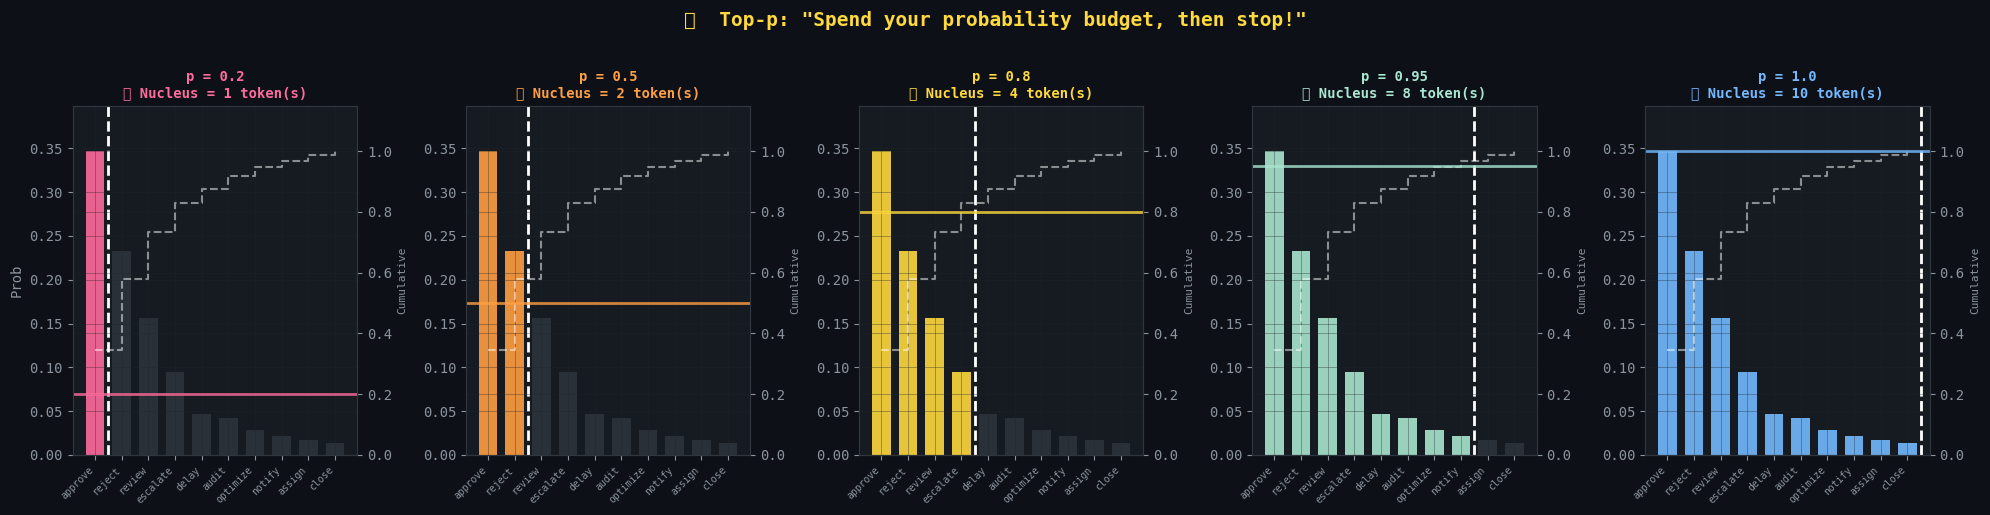


💡 The WHITE dashed line = the budget cutoff.
💡 The COLORED dashed line = where cumulative probability = p.
💡 Only the COLORED bars can be sampled!


In [2]:
# ── Graph 1: Budget Being Spent ──────────────────────────────────────
p_values = [0.2, 0.5, 0.8, 0.95, 1.0]
colors_p = ['#ff6b9d','#ff9f43','#ffd93d','#a8e6cf','#74b9ff']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('💰  Top-p: "Spend your probability budget, then stop!"',
             fontsize=14, fontweight='bold', color='#ffd93d', y=1.02)

sorted_idx   = np.argsort(PROBS)[::-1]
sorted_probs = PROBS[sorted_idx]
sorted_names = [TOKENS[i] for i in sorted_idx]

for ax, p, col in zip(axes, p_values, colors_p):
    _, cutoff, _ = apply_top_p(PROBS, p)
    cumsum = np.cumsum(sorted_probs)
    bar_colors = [col if i < cutoff else '#2d333b' for i in range(10)]
    bars = ax.bar(range(10), sorted_probs, color=bar_colors, width=0.7, alpha=0.9)
    # Show cumulative sum as a step line
    ax2 = ax.twinx()
    ax2.step(range(10), cumsum, where='post', color='white', lw=1.5, alpha=0.5, ls='--')
    ax2.axhline(p, color=col, lw=2, ls='-', alpha=0.8)
    ax2.set_ylim(0, 1.15); ax2.tick_params(colors='#8b949e')
    ax2.set_ylabel('Cumulative', color='#8b949e', fontsize=8)
    ax.axvline(cutoff - 0.5, color='white', lw=2, ls='--')
    ax.set_xticks(range(10)); ax.set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, max(sorted_probs)*1.15); ax.set_ylabel('Prob' if ax==axes[0] else '')
    ax.set_title(f'p = {p}\n🎯 Nucleus = {cutoff} token(s)', color=col, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('graph1_topp_budget.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\n💡 The WHITE dashed line = the budget cutoff.")
print("💡 The COLORED dashed line = where cumulative probability = p.")
print("💡 Only the COLORED bars can be sampled!")


## 🎬 Graph 2 — The Dynamic Property (The Superpower!)

This is the graph that explains why top-p is better than top-k in most cases.

**The same p=0.9 behaves completely differently on:**
- A CONFIDENT model (peaks at one token) → tiny nucleus (2–3 tokens)  
- An UNCERTAIN model (flat distribution) → large nucleus (8–12 tokens)

**Top-p adapts. Top-k doesn't.**


In [ ]:
# ── Graph 2: Dynamic Nucleus ─────────────────────────────────────────
rng = np.random.default_rng(0)
probs_peaked = softmax(np.array([4.0, 0.5, 0.2, 0.1, -0.1, -0.3, -0.5, -0.7, -0.9, -1.1]))
probs_flat   = softmax(np.array([0.5, 0.4, 0.3, 0.2, 0.1, 0.0,-0.1,-0.2,-0.3,-0.4]))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('🔮  The Dynamic Superpower: Same p=0.9, Very Different Results',
             fontsize=14, fontweight='bold', color='#ffd93d')

# Row 1: Peaked distribution
ax_pk = axes[0][0]
sorted_pk = np.sort(probs_peaked)[::-1]
_, cutoff_pk, _ = apply_top_p(probs_peaked, 0.9)
bar_c = ['#ff6b9d' if i < cutoff_pk else '#2d333b' for i in range(10)]
axes[0][0].bar(range(10), sorted_pk, color=bar_c, width=0.7, alpha=0.9)
axes[0][0].axvline(cutoff_pk-0.5, color='white', lw=2, ls='--')
axes[0][0].set_title(f'😎 Confident Model
→ p=0.9 needs only {cutoff_pk} token(s)!',
                     color='#ff6b9d', fontweight='bold')
axes[0][0].set_xlabel('Rank (sorted)'); axes[0][0].set_ylabel('Probability')

# Row 2: Flat distribution
sorted_fl = np.sort(probs_flat)[::-1]
_, cutoff_fl, _ = apply_top_p(probs_flat, 0.9)
bar_c2 = ['#74b9ff' if i < cutoff_fl else '#2d333b' for i in range(10)]
axes[1][0].bar(range(10), sorted_fl, color=bar_c2, width=0.7, alpha=0.9)
axes[1][0].axvline(cutoff_fl-0.5, color='white', lw=2, ls='--')
axes[1][0].set_title(f'🤔 Uncertain Model
→ p=0.9 needs {cutoff_fl} tokens!',
                     color='#74b9ff', fontweight='bold')
axes[1][0].set_xlabel('Rank (sorted)'); axes[1][0].set_ylabel('Probability')

# Cumulative curves
p_range = np.linspace(0.1, 1.0, 200)
sizes_pk = [apply_top_p(probs_peaked, p)[1] for p in p_range]
sizes_fl = [apply_top_p(probs_flat,   p)[1] for p in p_range]

axes[0][1].plot(p_range, sizes_pk, color='#ff6b9d', lw=2.5, label='Confident model')
axes[0][1].plot(p_range, sizes_fl, color='#74b9ff', lw=2.5, label='Uncertain model')
axes[0][1].fill_between(p_range, sizes_pk, sizes_fl, alpha=0.1, color='#ffd93d')
axes[0][1].axvline(0.9, color='#ffd93d', lw=2, ls='--', label='p=0.9')
axes[0][1].set_xlabel('p value'); axes[0][1].set_ylabel('Nucleus size (# tokens)')
axes[0][1].set_title('Nucleus Size vs p
(gap = how much top-p adapts)',
                     color='#ffd93d', fontweight='bold')
axes[0][1].legend(fontsize=9)
axes[1][1].axis('off')

# Comparison at p=0.9
categories = ['Confident', 'Uncertain']
sizes = [cutoff_pk, cutoff_fl]
col_compare = ['#ff6b9d', '#74b9ff']
axes[0][2].bar(categories, sizes, color=col_compare, width=0.5, alpha=0.9)
for i, (cat, sz) in enumerate(zip(categories, sizes)):
    axes[0][2].text(i, sz + 0.1, f'{sz} tokens', ha='center', va='bottom',
                   color='white', fontsize=14, fontweight='bold')
axes[0][2].set_ylabel('Tokens in nucleus at p=0.9')
axes[0][2].set_title('Same p=0.9
Wildly different nucleus sizes!', color='#ffd93d', fontweight='bold')
axes[0][2].set_ylim(0, cutoff_fl * 1.3)
axes[1][2].axis('off')
axes[1][2].text(0.5, 0.5,
    "🎯 KEY INSIGHT:

Top-p doesn't fix a number.
It fixes a PROBABILITY.

When the model is confident
→ few tokens needed
→ small nucleus

When uncertain
→ many tokens needed
→ large nucleus

The nucleus ADAPTS
automatically!",
    ha='center', va='center', transform=axes[1][2].transAxes,
    fontsize=11, color='#ffd93d', style='italic',
    bbox=dict(boxstyle='round,pad=0.8', facecolor='#21262d', edgecolor='#ffd93d'))

plt.tight_layout()
plt.savefig('graph2_topp_dynamic.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 🎬 Graph 3 — Renormalization: The Hidden Effect

After cutting the tail, probabilities are **rescaled** so they sum to 1.0 again.

**This boosts surviving tokens beyond their original probability.**

Watch what happens to "approve" as p decreases — its probability *rises* even though we haven't touched temperature.


In [ ]:
# ── Graph 3: Renormalization Effect ─────────────────────────────────
p_values3 = [0.2, 0.4, 0.6, 0.8, 1.0]
approve_probs = []
nucleus_sizes = []

for p in p_values3:
    filtered, cutoff, nucleus_idx = apply_top_p(PROBS, p)
    approve_idx = TOKENS.index('approve')
    approve_probs.append(filtered[approve_idx] if approve_idx in nucleus_idx else 0)
    nucleus_sizes.append(cutoff)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("🔄  Renormalization: The Hidden Probability Boost",
             fontsize=14, fontweight='bold', color='#ffd93d')

# Panel 1: How approve's probability changes with p
axes[0].plot(p_values3, approve_probs, color='#ff6b9d', lw=2.5, marker='o', ms=10)
axes[0].axhline(PROBS[0], color='#8b949e', lw=1.5, ls='--', label=f"Baseline: {PROBS[0]:.1%}")
for p, ap in zip(p_values3, approve_probs):
    axes[0].annotate(f'{ap:.1%}', (p, ap), textcoords='offset points',
                     xytext=(5, 8), color='#ff6b9d', fontsize=10, fontweight='bold')
axes[0].set_xlabel("Top-p value")
axes[0].set_ylabel("P('approve') after renormalization")
axes[0].set_title("'approve' probability rises as p shrinks!
(renormalization redistributes the cut probability)",
                  color='#ff6b9d', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].set_ylim(0, 1.05)

# Panel 2: Visual explanation of renormalization
ax2 = axes[1]; ax2.axis('off')
explanation = [
    ("Original (p=1.0):", PROBS),
    ("After p=0.5 cut:", apply_top_p(PROBS, 0.5)[0]),
    ("After p=0.2 cut:", apply_top_p(PROBS, 0.2)[0]),
]
ys = [0.75, 0.45, 0.15]
colors_exp = ['#8b949e', '#ff9f43', '#ff6b9d']
for (label, probs_ex), y, col in zip(explanation, ys, colors_exp):
    ax2.text(0.0, y + 0.08, label, transform=ax2.transAxes, color=col, fontsize=11, fontweight='bold')
    for i, (tok, p_val) in enumerate(zip(TOKENS[:5], probs_ex[:5])):
        ax2.barh([y], [p_val], left=[i * 0.18], height=0.06,
                color=col if p_val > 0 else '#2d333b', alpha=0.8, transform=ax2.transAxes)
        ax2.text(i * 0.18 + p_val / 2, y - 0.02, f'{p_val:.0%}',
                ha='center', va='top', transform=ax2.transAxes,
                color='white' if p_val > 0.02 else '#2d333b', fontsize=7)
ax2.set_title("Renormalization in Action (first 5 tokens)", color='#ffd93d', fontweight='bold')

plt.tight_layout()
plt.savefig('graph3_topp_renorm.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\n💡 'approve' at baseline: {:.1%}".format(PROBS[0]))
print("💡 'approve' after p=0.2 cut: {:.1%}".format(apply_top_p(PROBS, 0.2)[0][0]))
print("💡 That's a BOOST — because all the cut probability gets redistributed upward!")


## 🎮 Graph 4 — Your Top-p Playground

Change `P_VALUE` below and re-run to see:
- How the nucleus changes size
- How renormalization boosts surviving tokens
- What zone you're in


In [ ]:
# ── Graph 4: Playground ──────────────────────────────────────────────
P_VALUE = 0.9  # ← 🎮 CHANGE THIS! Try: 0.2, 0.5, 0.8, 0.9, 0.95, 1.0

filtered, cutoff, nucleus_idx = apply_top_p(PROBS, P_VALUE)
sorted_idx2 = np.argsort(PROBS)[::-1]
sorted_names2 = [TOKENS[i] for i in sorted_idx2]
sorted_orig  = PROBS[sorted_idx2]
sorted_filt  = filtered[sorted_idx2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'🎮 Your Playground — p = {P_VALUE}', fontsize=15,
             fontweight='bold', color='#ffd93d')

x = np.arange(10); w = 0.4
bars1 = ax1.bar(x - w/2, sorted_orig, width=w, color='#8b949e', alpha=0.6, label='Before top-p')
bars2 = ax1.bar(x + w/2, sorted_filt, width=w, color='#a8e6cf', alpha=0.9, label='After top-p + renorm')
ax1.axvline(cutoff - 0.5, color='#ffd93d', lw=2.5, ls='--', label=f'Cutoff at rank {cutoff}')
ax1.set_xticks(x); ax1.set_xticklabels(sorted_names2, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Probability'); ax1.set_ylim(0, max(sorted_orig)*1.2)
ax1.legend(fontsize=9)
ax1.set_title(f'Before vs After top-p={P_VALUE}\n{cutoff} tokens in nucleus',
              color='#a8e6cf', fontweight='bold')

p_range3 = np.linspace(0.05, 1.0, 300)
sizes3 = [apply_top_p(PROBS, p)[1] for p in p_range3]
ax2.plot(p_range3, sizes3, color='#74b9ff', lw=2.5)
ax2.scatter([P_VALUE], [cutoff], s=250, color='#ffd93d', zorder=10,
            edgecolors='white', linewidth=2)
ax2.axvline(P_VALUE, color='#ffd93d', lw=1.5, ls='--')
zones3 = [(0,.5,'#ff6b9d','Tight'),(0.5,.8,'#ff9f43','Moderate'),(0.8,.95,'#a8e6cf','Standard'),(0.95,1,'#74b9ff','Open')]
for x0,x1,col,lbl in zones3:
    ax2.axvspan(x0,x1,alpha=0.08,color=col)
    ax2.text((x0+x1)/2, 9.3, lbl, ha='center', color=col, fontsize=9, fontweight='bold')
ax2.set_xlabel('p value'); ax2.set_ylabel('Nucleus size')
ax2.set_title(f'You are here: p={P_VALUE} → {cutoff} token(s)', color='#ffd93d', fontweight='bold')

print(f"📊 Stats for p={P_VALUE}:")
print(f"   Nucleus size: {cutoff} tokens")
print(f"   Surviving tokens: {[sorted_names2[i] for i in range(cutoff)]}")
print(f"   Top token after renorm: '{sorted_names2[0]}' at {sorted_filt[0]:.1%}")

plt.tight_layout()
plt.savefig('graph4_topp_playground.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## ✅ Notebook 2 Complete

| Concept | In One Line |
|---|---|
| Top-p | Keep the smallest set of tokens whose probabilities sum to ≥ p |
| Dynamic | Nucleus shrinks when model is confident, grows when uncertain |
| Renormalization | After cutting, surviving tokens' probs are rescaled to sum to 1.0 |
| p=0.9 | The standard default — keeps 90% of the probability mass |
| p=1.0 | No filtering (identical to not using top-p) |

> **🎯 Budget metaphor holds:** p=0.9 means "spend 90 cents of your dollar on the best tokens, ignore the pennies."

**Next → `03_top_k.ipynb`: The VIP List 🎫**
